# Standalone BEAST Experiment

In [1]:
print("hello")

hello


### Set Up Models

In [3]:
device = "cuda" # Recommended to use L4 GPU on Google Colab
# device = "cpu" # Recommended to use L4 GPU on Google Colab

In [4]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

/workspace/inversion_optimisation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Set up target/ judge model

# model_name = "meta-llama/Llama-3.2-1B-Instruct"
# model_name = "meta-llama/Llama-3.2-3B-Instruct"
# model_template_prefix_string = "<|begin_of_text|><|start_header_id|>user<|end_header_id|>\n\n"
# model_template_postfix_string = "<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n"

# model_name = "Qwen/Qwen2.5-1.5B-instruct"
# model_name = "Qwen/Qwen2.5-3B-instruct"
# model_name = "Qwen/Qwen2.5-7B-instruct"
# model_template_prefix_string = "<|begin_of_text|><|start_header_id|>user<|end_header_id|>\n\n"
# model_template_postfix_string = "<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n"

# model_name = "Qwen/Qwen3-1.7B"
model_name = "Qwen/Qwen3-4B"
model_template_prefix_string = "<|im_start|>user\n"
model_template_postfix_string = "<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n\n"

# model_name = "google/gemma-2b-it"
# model_name = "google/gemma-7b-it"
# model_template_prefix_string = "<bos><start_of_turn>user\n"
# model_template_postfix_string = "<end_of_turn>\n<start_of_turn>model\n"

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map=device,
    torch_dtype=torch.float16,
    use_cache=False,
    low_cpu_mem_usage=True,
)
model.eval()
_tokenizer = AutoTokenizer.from_pretrained(model_name)
if _tokenizer.pad_token is None:
    _tokenizer.pad_token = _tokenizer.eos_token
model.tokenizer = _tokenizer
del _tokenizer
print(f"Model loaded: {model_name}")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards: 100%|██████████| 3/3 [00:02<00:00,  1.33it/s]


Model loaded: Qwen/Qwen3-4B


### Perplexity combinatorial search

Prefix: '<|im_start|>user\n'
Prefix token IDs: [151644, 872, 198]
Vocab size: 151643
EOS token ID: 151645



=== Threshold: 0.1 ===
  Depth    Active          Cumul Active    Min Prob        Max Prob        Time        
  -------------------------------------------------------------------------------------
  0        1               1               1.00000000      1.00000000      —           
  1        4               5               0.15795898      0.24841309      0.04        s


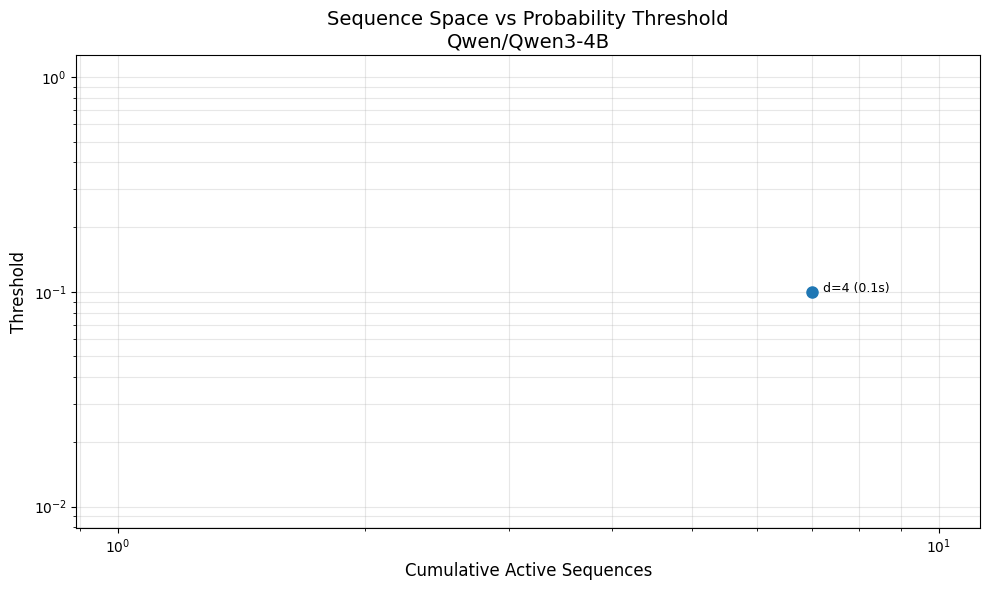


Results summary:
Threshold       Cumul Active    Max Depth  Time      
--------------------------------------------------
0.1             7               4          0.11      s


=== Threshold: 0.01 ===
  Depth    Active          Cumul Active    Min Prob        Max Prob        Time        
  -------------------------------------------------------------------------------------
  0        1               1               1.00000000      1.00000000      —           
  1        8               9               0.01296234      0.24841309      0.02        s


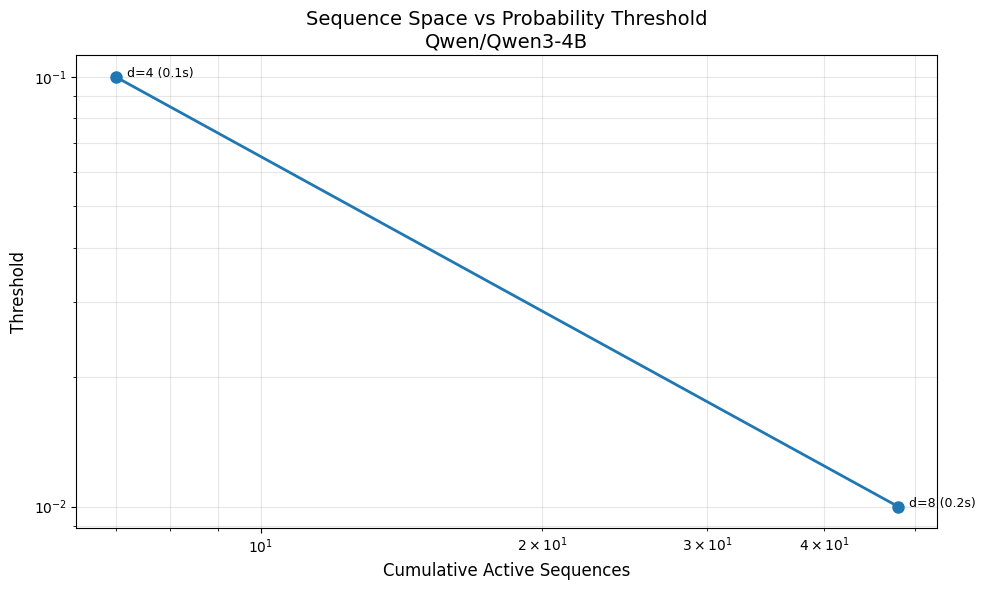


Results summary:
Threshold       Cumul Active    Max Depth  Time      
--------------------------------------------------
0.1             7               4          0.11      s
0.01            48              8          0.18      s


=== Threshold: 0.001 ===
  Depth    Active          Cumul Active    Min Prob        Max Prob        Time        
  -------------------------------------------------------------------------------------
  0        1               1               1.00000000      1.00000000      —           
  1        32              33              0.00111485      0.24841309      0.02        s


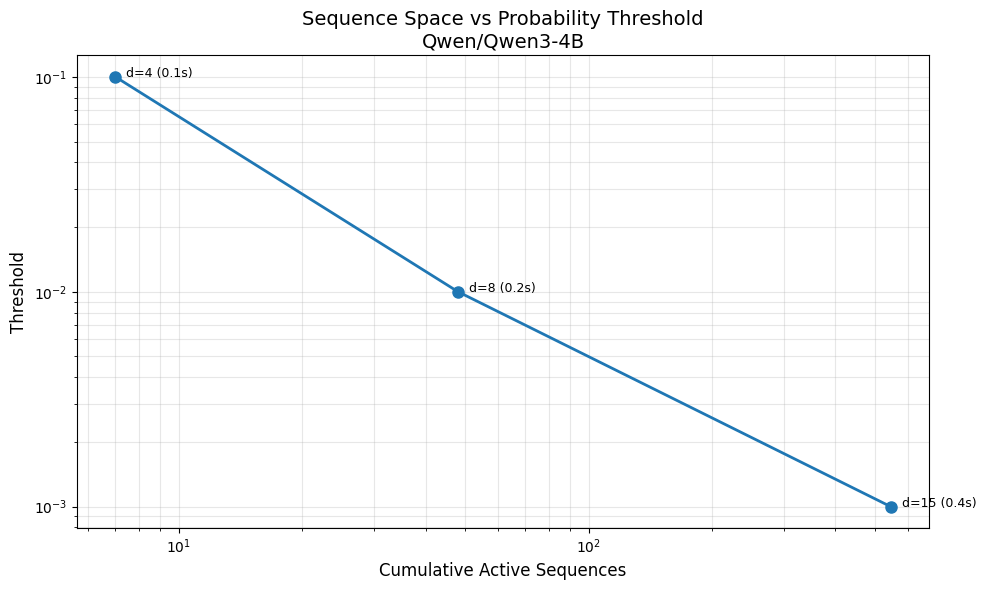


Results summary:
Threshold       Cumul Active    Max Depth  Time      
--------------------------------------------------
0.1             7               4          0.11      s
0.01            48              8          0.18      s
0.001           546             15         0.43      s


=== Threshold: 0.0001 ===
  Depth    Active          Cumul Active    Min Prob        Max Prob        Time        
  -------------------------------------------------------------------------------------
  0        1               1               1.00000000      1.00000000      —           
  1        74              75              0.00010133      0.24841309      0.02        s


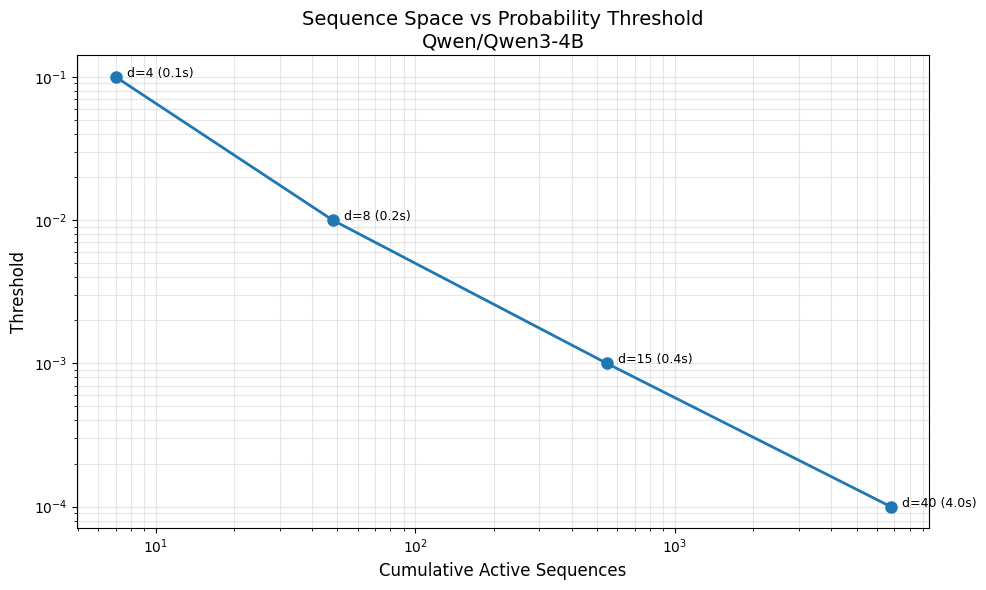


Results summary:
Threshold       Cumul Active    Max Depth  Time      
--------------------------------------------------
0.1             7               4          0.11      s
0.01            48              8          0.18      s
0.001           546             15         0.43      s
0.0001          6772            40         3.96      s


=== Threshold: 1e-05 ===
  Depth    Active          Cumul Active    Min Prob        Max Prob        Time        
  -------------------------------------------------------------------------------------
  0        1               1               1.00000000      1.00000000      —           
  1        227             228             0.00001001      0.24841309      0.03        s
  51       58              83379           0.00001002      0.00009659      0.16        s
  101      13              84729           0.00001017      0.00008695      0.08        s
  151      9               85238           0.00001007      0.00007873      0.08        s
  201     

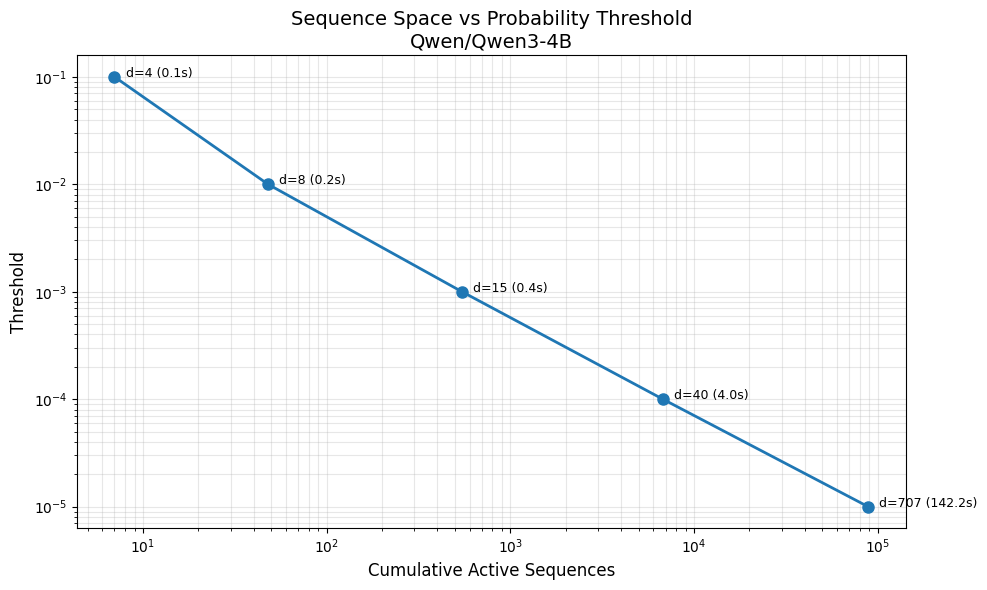


Results summary:
Threshold       Cumul Active    Max Depth  Time      
--------------------------------------------------
0.1             7               4          0.11      s
0.01            48              8          0.18      s
0.001           546             15         0.43      s
0.0001          6772            40         3.96      s
1e-05           88644           707        142.16    s


=== Threshold: 1.0000000000000002e-06 ===
  Depth    Active          Cumul Active    Min Prob        Max Prob        Time        
  -------------------------------------------------------------------------------------
  0        1               1               1.00000000      1.00000000      —           
  1        771             772             0.00000101      0.24841309      0.04        s
  51       1357            957303          0.00000100      0.00009669      4.06        s
  101      426             992690          0.00000100      0.00008676      2.52        s
  151      289             

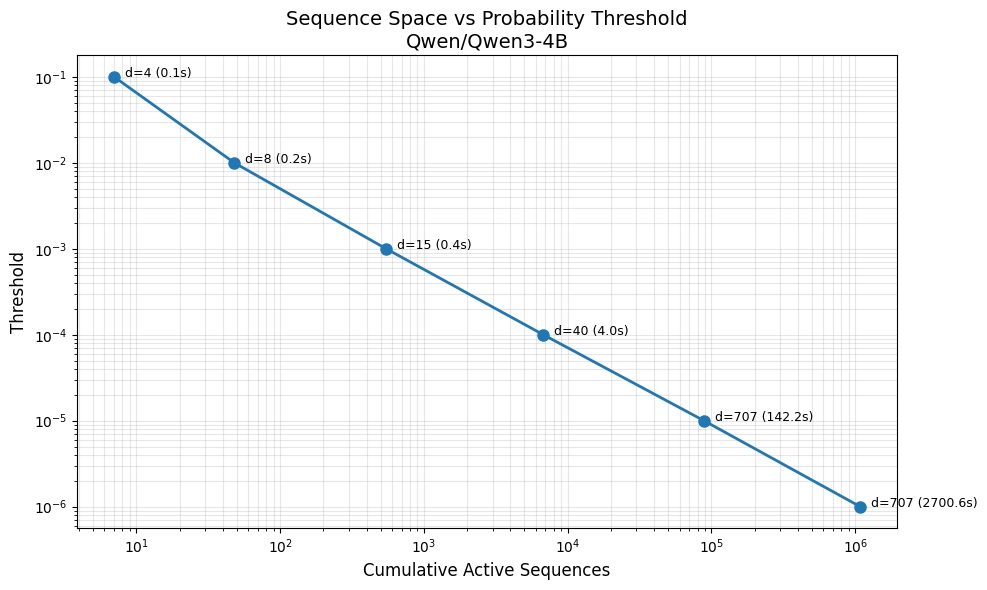


Results summary:
Threshold       Cumul Active    Max Depth  Time      
--------------------------------------------------
0.1             7               4          0.11      s
0.01            48              8          0.18      s
0.001           546             15         0.43      s
0.0001          6772            40         3.96      s
1e-05           88644           707        142.16    s
1.0000000000000002e-06 1082479         707        2700.61   s


=== Threshold: 1.0000000000000002e-07 ===
  Depth    Active          Cumul Active    Min Prob        Max Prob        Time        
  -------------------------------------------------------------------------------------
  0        1               1               1.00000000      1.00000000      —           
  1        3590            3591            0.00000012      0.24841309      0.10        s


KeyboardInterrupt: 

In [24]:
import torch
import torch.nn.functional as F
import time
import matplotlib.pyplot as plt
import numpy as np

# === Configuration ===
batch_size = 512
prefix_string = model_template_prefix_string
device = next(model.parameters()).device
log_x = True
log_y = True
max_depth = 32768
stagnation_limit = 100

# === Encode the prefix ===
prefix_ids = model.tokenizer.encode(prefix_string, add_special_tokens=False)
eos_token_id = model.tokenizer.eos_token_id

print(f"Prefix: {repr(prefix_string)}")
print(f"Prefix token IDs: {prefix_ids}")
print(f"Vocab size: {model.tokenizer.vocab_size}")
print(f"EOS token ID: {eos_token_id}")
print()

results = []  # (threshold, cumulative_active, max_depth, elapsed)

threshold = 1.0
while True:
    threshold /= 10
    active_sequences = [([], 1.0)]
    cumulative_active = 1
    depth = 0
    prev_max_p = 1.0
    stagnation_count = 0

    t_total_start = time.time()

    print(f"\n\n=== Threshold: {threshold} ===")
    print(f"  {'Depth':<8} {'Active':<15} {'Cumul Active':<15} {'Min Prob':<15} {'Max Prob':<15} {'Time':<12}")
    print(f"  {'-' * 85}")

    while active_sequences and depth < max_depth:
        depth += 1
        next_active = []

        t_start = time.time()
        for batch_start in range(0, len(active_sequences), batch_size):
            batch = active_sequences[batch_start:batch_start + batch_size]

            input_ids_list = [prefix_ids + seq_tokens for seq_tokens, _ in batch]
            max_len = max(len(ids) for ids in input_ids_list)

            pad_id = model.tokenizer.pad_token_id
            padded = []
            attention_masks = []
            for ids in input_ids_list:
                pad_len = max_len - len(ids)
                padded.append([pad_id] * pad_len + ids)
                attention_masks.append([0] * pad_len + [1] * len(ids))

            input_tensor = torch.tensor(padded, device=device)
            attention_mask = torch.tensor(attention_masks, device=device)

            with torch.no_grad():
                outputs = model(input_ids=input_tensor, attention_mask=attention_mask)
                last_logits = outputs.logits[:, -1, :]
                probs = F.softmax(last_logits, dim=-1)

            for i, (seq_tokens, cum_prob) in enumerate(batch):
                token_probs = probs[i]
                min_next_prob = threshold / cum_prob

                valid_mask = token_probs >= min_next_prob
                valid_indices = valid_mask.nonzero(as_tuple=True)[0]

                for idx in valid_indices:
                    token_id = idx.item()
                    token_prob = token_probs[idx].item()
                    new_cum_prob = cum_prob * token_prob

                    if token_id != eos_token_id:
                        next_active.append((seq_tokens + [token_id], new_cum_prob))

            del input_tensor, attention_mask, outputs, last_logits, probs

        active_sequences = next_active
        cumulative_active += len(active_sequences)

        if active_sequences:
            max_p = max(p for _, p in active_sequences)
            if max_p >= prev_max_p:  # not decaying meaningfully
                stagnation_count += 1
            else:
                stagnation_count = 0
            prev_max_p = max_p
        
        if stagnation_count >= stagnation_limit:
            print(f"  Stagnation detected at depth {depth} (max_prob ~{prev_max_p:.8f} for {stagnation_limit} steps)")
            print(f"  Active sequences:")
            for seq_tokens, cum_prob in active_sequences[:10]:
                text = model.tokenizer.decode(seq_tokens)
                print(f"    p={cum_prob:.8f}: {repr(text[:100])}")
            break

        if ((depth-1) % 50) == 0:
            elapsed = time.time() - t_start
            if active_sequences:
                probs_list = [p for _, p in active_sequences]
                min_p = min(probs_list)
            else:
                min_p = max_p = 0.0

            print(f"  {depth:<8} {len(active_sequences):<15} {cumulative_active:<15} {min_p:<15.8f} {max_p:<15.8f} {elapsed:<12.2f}s")

    if depth >= max_depth and active_sequences:
        print(f"\n  Stopped at max_depth={max_depth}, {len(active_sequences)} sequences still active:")
        for seq_tokens, cum_prob in active_sequences[:10]:
            text = model.tokenizer.decode(seq_tokens)
            print(f"    p={cum_prob:.8f}: {repr(text[:100])}")

    t_total = time.time() - t_total_start
    results.append((threshold, cumulative_active, depth, t_total))

    # === Plot ===
    thresholds_plot = [r[0] for r in results]
    cumulative_plot = [r[1] for r in results]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(cumulative_plot, thresholds_plot, 'o-', markersize=8, linewidth=2)

    if log_x:
        ax.set_xscale('log')
    if log_y:
        ax.set_yscale('log')

    ax.set_xlabel('Cumulative Active Sequences', fontsize=12)
    ax.set_ylabel('Threshold', fontsize=12)
    ax.set_title(f'Sequence Space vs Probability Threshold\n{model_name}', fontsize=14)
    ax.grid(True, which='both', alpha=0.3)

    for t, c, d, elapsed in results:
        ax.annotate(f'd={d} ({elapsed:.1f}s)', (c, t), textcoords="offset points", xytext=(8, 0), fontsize=9)

    plt.tight_layout()
    plt.savefig('threshold_scaling.png', dpi=150)
    plt.show()

    print("\nResults summary:")
    print(f"{'Threshold':<15} {'Cumul Active':<15} {'Max Depth':<10} {'Time':<10}")
    print("-" * 50)
    for t, c, d, elapsed in results:
        print(f"{t:<15} {c:<15} {d:<10} {elapsed:<10.2f}s")